# New Section

In [7]:
import pandas as pd
import json

file_path = "/content/sample_data/clean_150k.jsonl"

data = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            continue

df = pd.DataFrame(data)

print(df.head())
print(df.columns)

                                         instruction  \
0  What is the difference between Intel and PPC? ...   
1  Turn on Back To My Mac via a Script or Command...   
2  Why doesn't Microsoft Office/2008(& later) sup...   
3  Repair Disk - Start up disk options I had a po...   
4  How can I make focus follow the mouse cursor? ...   

                                            response  
0  When it comes to Apple hardware, the differenc...  
1  There is no supported way to do this. Having s...  
2  “Why” is a question for Microsoft, but I'm gue...  
3  One option would be to clone your startup driv...  
4  This is freely possible for the Terminal and X...  
Index(['instruction', 'response'], dtype='object')


# New Section

In [8]:
df['text'] = df['instruction'].astype(str) + " " + df['response'].astype(str)
df['token_length'] = df['text'].apply(lambda x: len(x.split()))
df['response_length'] = df['response'].astype(str).apply(lambda x: len(x.split()))

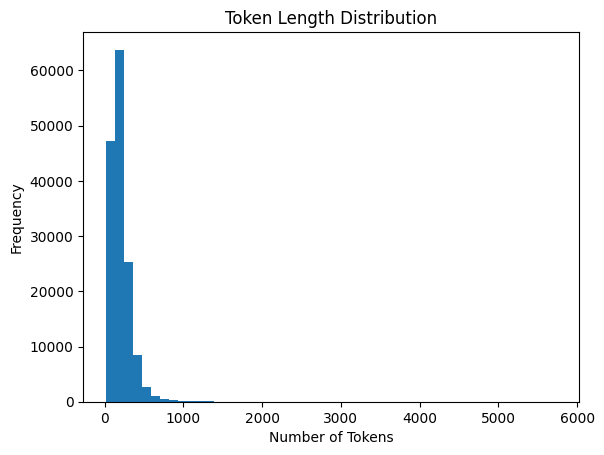

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['token_length'], bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

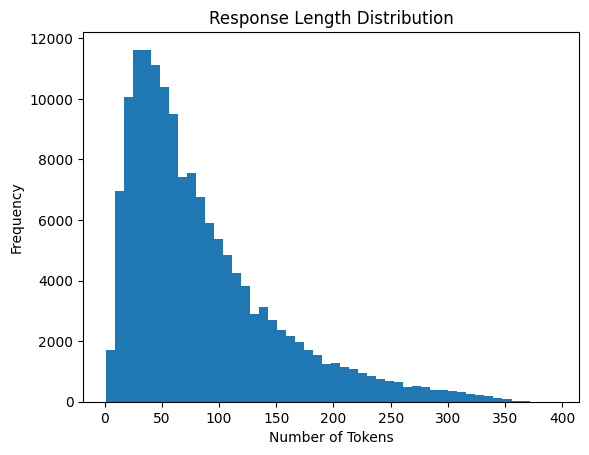

In [10]:
plt.figure()
plt.hist(df['response_length'], bins=50)
plt.title("Response Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# 1. Split: 70% train, 30% test
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# 2. Add labels
train_df = train_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
test_df['split'] = 'test'

# 3. Merge correctly
df_split = pd.concat([train_df, test_df])



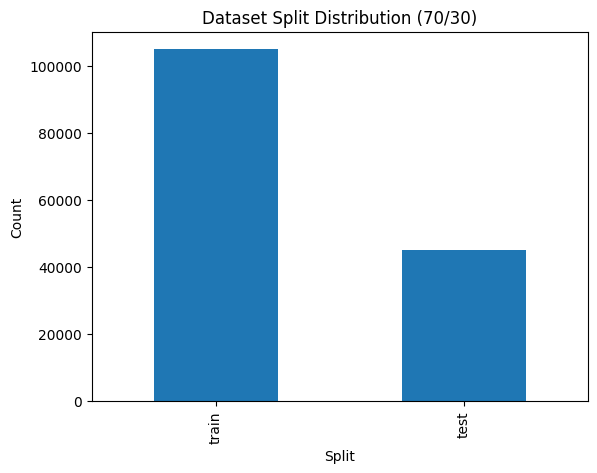

In [21]:
# 4. Plot
plt.figure()
df_split['split'].value_counts().plot(kind='bar')
plt.title("Dataset Split Distribution (70/30)")
plt.xlabel("Split")
plt.ylabel("Count")
plt.show()